# Analyzing Customer Transaction Patterns for Online Sales Growth.

<img src="https://i.pinimg.com/1200x/82/fd/a3/82fda315cd1e0e444bad996f4a367624.jpg" width="500" border="0" style="display: block; margin-left: auto; margin-right: auto;">


**Final Project:** Muthi'ah  
**Mentor:** Mega Bagus Herlambang, PhD  
**Data Contributor:** Al-Fath TSA (Retail Store)  
**Case Study:** Sales Data from October–December 2024

<hr><br>

### 📖 Project Statement

This project analyzes customer transaction data from October–December 2024 to identify purchasing patterns, compare reseller vs. non-reseller contributions, and uncover opportunities to increase repeat purchases and overall online sales growth.

### 🎯 Objectives of Analysis:
* Identify customer characteristics that contribute the most to sales.
* Understand customer transaction patterns and purchasing trends.
* Discover opportunities for customer retention and strategies to enhance loyalty.

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns

## 📄Data Preparation

In [2]:
sales_data = 'sales_data_oct-dec2024.xlsx'

## October 2024

In [3]:
period = 'October 2024'
df = pd.read_excel(sales_data, sheet_name='october2024')
df.head()

,Date,ID Customer,Name,Registered in the Form,Reseller,Total Sales
0,2024-10-01,CT17,Bu Yuyun,0,0,65000
1,2024-10-01,CT93,bu FITRI,0,1,54000
2,2024-10-01,CT92,FAIZAH,0,0,8000
3,2024-10-03,AF0001,ABU AISYAH,1,0,64000
4,2024-10-04,CT96,MAMA AI,0,1,165000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    140 non-null    datetime64[ns]
 1   ID Customer             140 non-null    object        
 2   Name                    140 non-null    object        
 3   Registered in the Form  140 non-null    int64         
 4   Reseller                140 non-null    int64         
 5   Total Sales             140 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 6.7+ KB


In [5]:
# Convert columns with only 2 unique integer values to category type
cols = ['Registered in the Form', 'Reseller']
df[cols] = df[cols].astype('category')

In [6]:
df.dtypes

Date                      datetime64[ns]
ID Customer                       object
Name                              object
Registered in the Form          category
Reseller                        category
Total Sales                        int64
dtype: object

## 📊 Exploratory Analysis

In [7]:
df.describe()

,Date,Total Sales
count,140,140.000000
mean,2024-10-20 04:27:25.714285824,97862.500000
min,2024-10-01 00:00:00,4000.000000
25%,2024-10-17 00:00:00,40000.000000
50%,2024-10-23 00:00:00,72250.000000
75%,2024-10-26 00:00:00,125000.000000
max,2024-10-31 00:00:00,590000.000000
std,NaN,95956.027498


In [8]:
# Calculate the coefficient of variation (CV)
def calculate_cv(file_path, sheet_name, column_name):
    data = pd.read_excel(file_path, sheet_name=sheet_name)
    mean = np.mean(data[column_name])
    std_dev = np.std(data[column_name], ddof=0)  # Using ddof=0 for population

    if mean == 0:
        return None, "Mean is zero, CV cannot be calculated."

    cv = (std_dev / mean) * 100

    # Determine variation category
    if cv < 10:
        assessment = "Low variation (Data is very homogeneous and changes little.)"
    elif 10 <= cv <= 20:  # Range between 10 and 20 (inclusive)
        assessment = "Moderate variation (Data varies somewhat but is relatively stable.)"
    else:
        assessment = "High variation (Data fluctuates widely and is not stable.)"

    return cv, assessment

In [9]:
cv, assessment = calculate_cv(sales_data, "october2024", "Total Sales")

print(f"‣ Coefficient of Variation (CV): {cv:.2f}%")
print(f"‣ Assessment: {assessment}")

‣ Coefficient of Variation (CV): 97.70%
‣ Assessment: High variation (Data fluctuates widely and is not stable.)


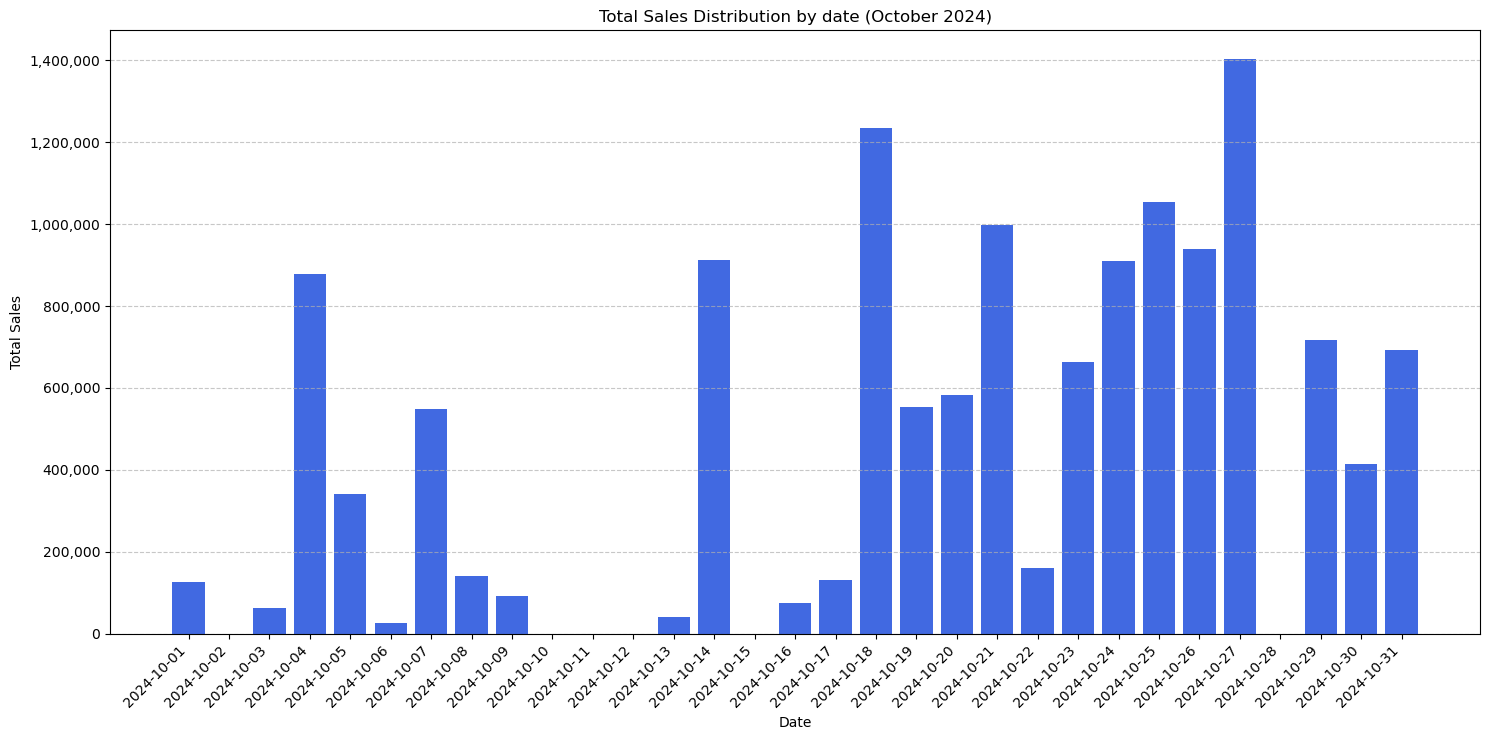

In [10]:
# Bar Chart of total sales distribution per date
df_grouped = df.groupby("Date", as_index=False)["Total Sales"].sum()

# Create a complete date range from the start to the end of the month
date_range = pd.date_range(start=df_grouped["Date"].min(), end=df_grouped["Date"].max())

# Reindex to include missing dates with 0 sales
df_grouped = df_grouped.set_index("Date").reindex(date_range, fill_value=0).reset_index()
df_grouped.rename(columns={"index": "Date"}, inplace=True)

# Plot the bar chart
fig, ax = plt.subplots(figsize=(15, 7.5))
ax.bar(df_grouped["Date"], df_grouped["Total Sales"], color="royalblue", align="center")

# Format y-axis with commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Format x-axis dates
ax.set_xticks(df_grouped["Date"])
ax.set_xticklabels(df_grouped["Date"].dt.strftime("%Y-%m-%d"), rotation=45, ha="right")

# Set labels and title
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales")
ax.set_title("Total Sales Distribution by date (October 2024)")

# Add horizontal grid lines
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [11]:
# Total sales from October 24–27
sales_24_27 = df[
    (df["Date"] >= "2024-10-24") &
    (df["Date"] <= "2024-10-27")
]["Total Sales"].sum()

# Total sales in October
total_october_sales = df["Total Sales"].sum()

# Percentage contribution of sales from October 24–27 to total October sales
percentage_24_27 = (sales_24_27 / total_october_sales) * 100

print(f"‣ Total sales from October 24–27: {sales_24_27:,.2f}.")
print(
    f"‣ Percentage contribution of sales from October 24–27 "
    f"to total October sales: {percentage_24_27:,.2f}%."
)


‣ Total sales from October 24–27: 4,305,500.00.
‣ Percentage contribution of sales from October 24–27 to total October sales: 31.43%.


In [12]:
mode_registered = df['Registered in the Form'].mode()[0]

if mode_registered == 0:
    assessment = "The majority of customers are not registered."
elif mode_registered == 1:
    assessment = "The majority of customers are registered."

print(f"‣ {assessment} ({mode_registered}).")


‣ The majority of customers are not registered. (0).


In [13]:
modus_reseller = df['Reseller'].mode()[0]

if modus_reseller == 0:
    assessment = "The majority of customers are not resellers."
elif modus_reseller == 1:
    assessment = "The majority of customers are resellers."

print(f"‣ {assessment} ({modus_reseller}).")

‣ The majority of customers are not resellers. (0).


In [14]:
# Average Transaction Per Person
# Remove duplicate customers to count the number of customers
unique_customers = df.drop_duplicates(subset=['ID Customer'])  # unique customers in dataframe form
number_of_customers = len(unique_customers)
print(f"‣ Number of customers who made transactions in {period}: {number_of_customers}")

# Calculate total transactions
total_transactions = df['Total Sales'].sum()
formatted_total_transactions = f"{total_transactions:,}".replace(",", ".")
print(f"‣ Total sales in {period}: {formatted_total_transactions}")

average_transaction_per_person = total_transactions / number_of_customers
print(f"‣ Average sales per person in {period}: {average_transaction_per_person:,.2f}")

‣ Number of customers who made transactions in October 2024: 82
‣ Total sales in October 2024: 13.700.750
‣ Average sales per person in October 2024: 167,082.32


In [15]:
# Reseller Transaction Analysis

# Filter transactions from Resellers
reseller_transactions = df.loc[df['Reseller'] == 1, 'Total Sales']

# Calculate total sales from Resellers
total_reseller_sales = reseller_transactions.sum()
total_reseller_sales_formatted = f"{total_reseller_sales:,}".replace(",", ".")
print(f"‣ Total sales from Resellers during {period}: {total_reseller_sales_formatted}")


# Number of reseller transactions
number_of_reseller_transactions = df[df['Reseller'] == 1].shape[0]
print(f"‣ Number of reseller transactions during {period}: {number_of_reseller_transactions}")

# Average reseller sales per transaction
average_reseller_sales = total_reseller_sales / number_of_reseller_transactions
average_reseller_sales_formatted = f"{average_reseller_sales:,.0f}".replace(",", ".")
print(f"‣ Average reseller sales during {period}: {average_reseller_sales_formatted}")


‣ Total sales from Resellers during October 2024: 7.142.000
‣ Number of reseller transactions during October 2024: 51
‣ Average reseller sales during October 2024: 140.039


In [16]:
unregistered_customers_october = len(
    df[df['Registered in the Form'] == 0].drop_duplicates(subset=['ID Customer'])
)

registered_customers_october = 173

print(
    f"‣ Number of unregistered customers who made transactions during {period}: "
    f"{unregistered_customers_october}"
)


‣ Number of unregistered customers who made transactions during October 2024: 49


#### 📊 Analisis Pareto (80/20)

In [17]:
# Total Customers
total_customers = unregistered_customers_october + registered_customers_october
print(f"‣ Total Customers: {total_customers}")

‣ Total Customers: 222


In [18]:
# Presentase Custoemr yang aktif dalam sebulan
customer_percentage = (number_of_customers / total_customers) * 100
print(f"‣ Active Customer Percentage for {period} : {customer_percentage:.2f}%")
print(f"‣ In {period}, {customer_percentage:.2f}% of customers generated total transactions of {formatted_total_transactions}")

‣ Active Customer Percentage for October 2024 : 36.94%
‣ In October 2024, 36.94% of customers generated total transactions of 13.700.750


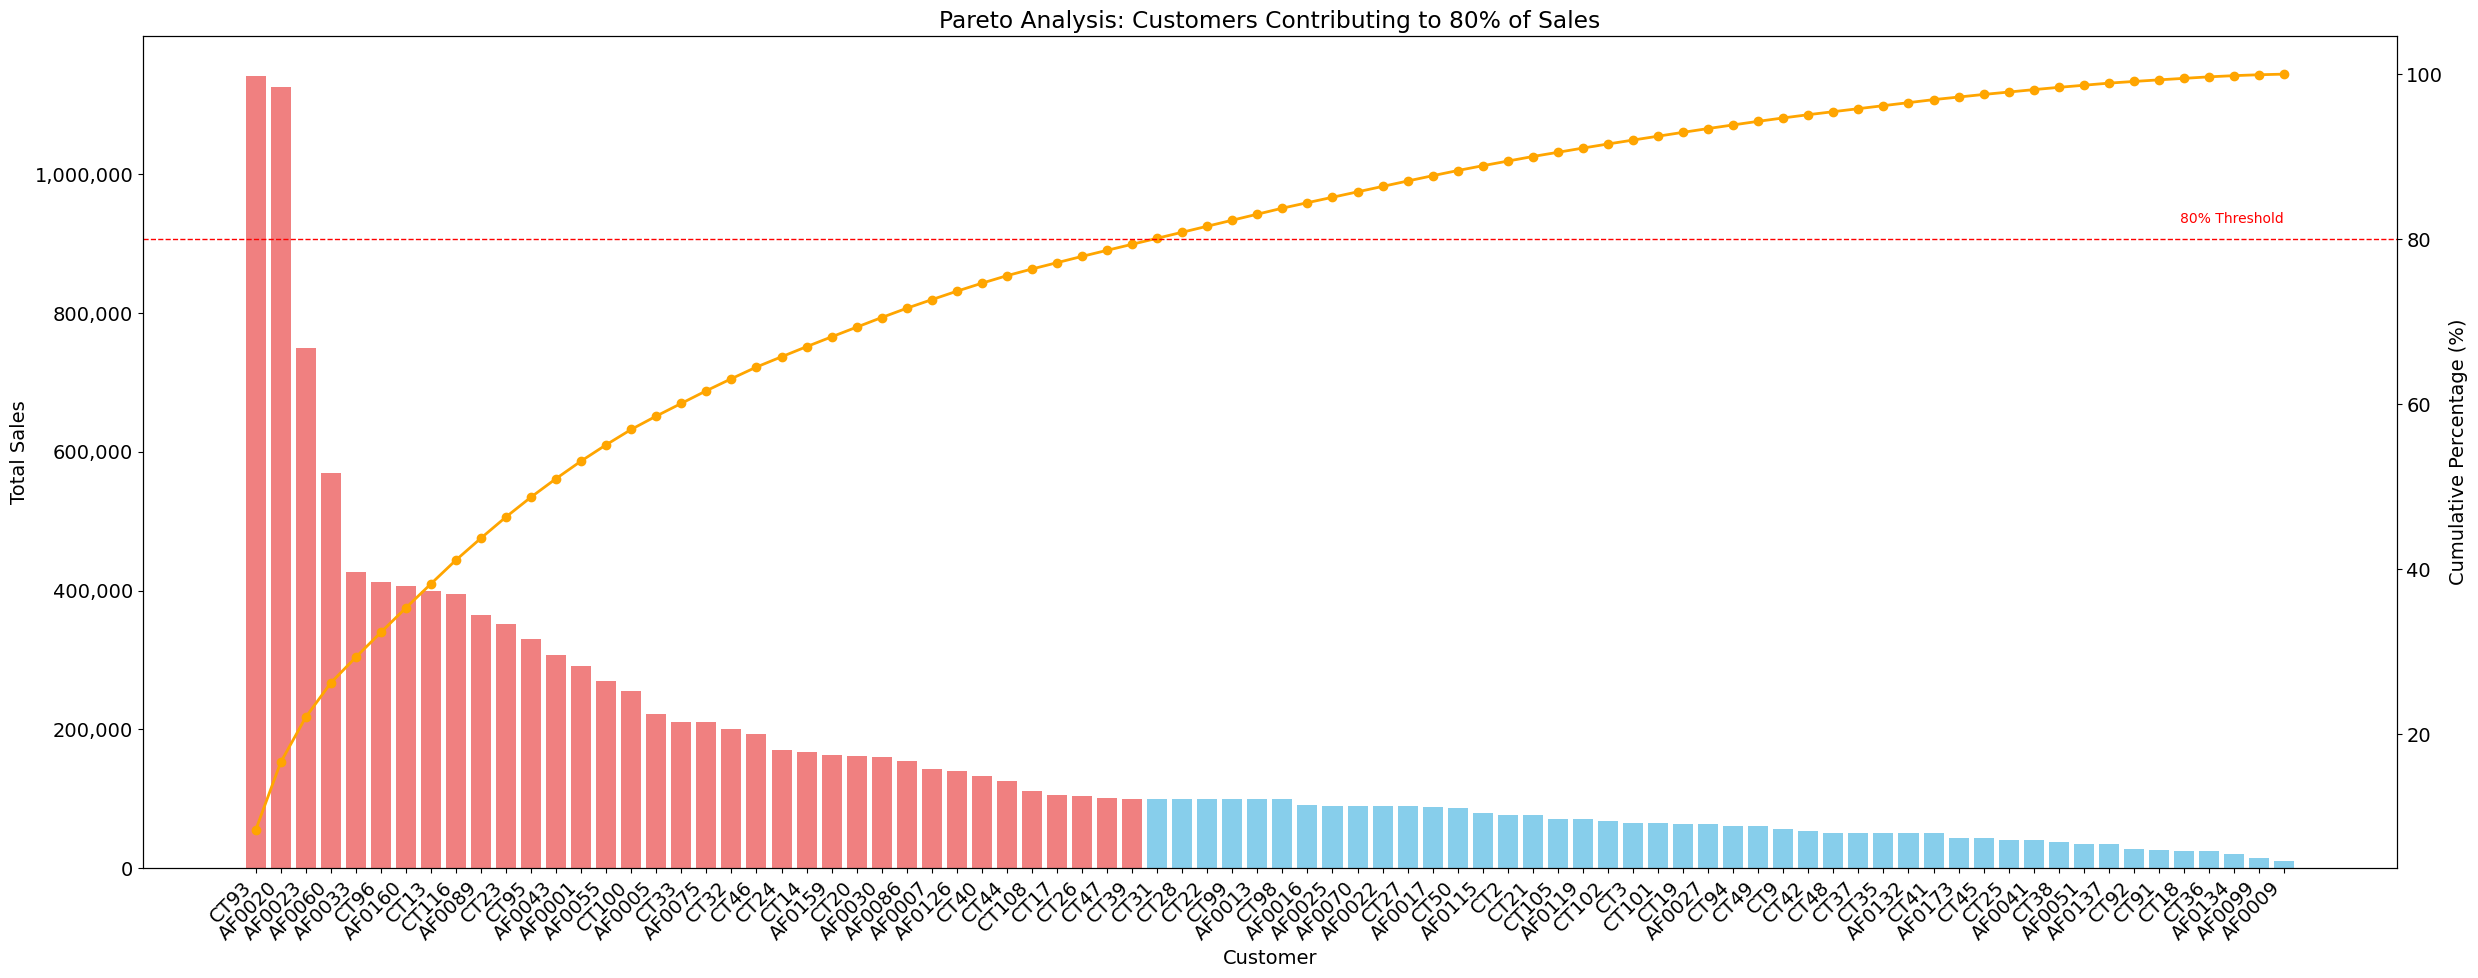

In [19]:
# Pareto Analysis using a Pareto Chart.
grouped_df = df.drop(columns=["Date", "Registered in the Form", "Reseller"]).groupby("ID Customer").sum().reset_index()
grouped_df = grouped_df.sort_values(by="Total Sales", ascending=False)

grouped_df["Cumulative Percentage"] = 100 * grouped_df["Total Sales"].cumsum() / grouped_df["Total Sales"].sum()

# 4. Identify customers contributing up to 80% of total sales.
grouped_df["Above 80%"] = grouped_df["Cumulative Percentage"] <= 80  
''' 
Result = By creating a new column (Above 80%) with True 
if the customer contributes up to 80%, and False otherwise.
'''

# Visualization plot.
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(25, 10))

'''
Bar colors:
lightcoral (light red): For customers included in the 80% contribution.
skyblue (blue): For customers outside the 80% contribution.
'''

ax.bar(
    grouped_df["ID Customer"], 
    grouped_df["Total Sales"], 
    color=np.where(grouped_df["Above 80%"], "lightcoral", "skyblue")
)

# f'{int(x):,}' converts x into an integer and displays it with thousands separators (1,000 instead of 1000).
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = ax.twinx()

# Cumulative percentage contribution line.
ax2.plot(
    grouped_df["ID Customer"], 
    grouped_df["Cumulative Percentage"], 
    color="orange", 
    marker="o", 
    linestyle="-", 
    linewidth=2
)

# 80% threshold line
ax2.axhline(y=80, color="red", linestyle="--", linewidth=1)
ax2.text(len(grouped_df) - 1, 82, "80% Threshold", color="red", fontsize=10, ha="right")

# Labels, Title, and Display
ax.set_title("Pareto Analysis: Customers Contributing to 80% of Sales")
ax.set_xlabel("Customer")
ax.set_ylabel("Total Sales")
ax2.set_ylabel("Cumulative Percentage (%)")

ax.set_xticks(range(len(grouped_df)))
ax.set_xticklabels(grouped_df["ID Customer"], rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [20]:
top_80 = grouped_df[grouped_df['Cumulative Percentage'] <= 80]

percentage_customers = (len(top_80) / total_customers) * 100

print(f"‣ 80% of total sales : {top_80['Total Sales'].sum():,.2f}")
print(f"‣ Number of customers contributing to 80% of sales: {len(top_80)}")
print(f"‣ Percentage of customers contributing to 80% of sales: {percentage_customers:.2f}%")
print(f"‣ Percentage of transactions contributing to 80% of sales: {((len(top_80) / df['Total Sales'].count()) * 100):.2f}%")

# Display dataframe that only contains customers contributing to 80% of sales
print(f"‣ List of customer names contributing to 80% of sales:")

df_sorted = df.groupby('ID Customer').agg({
    'Name': 'first',
    'Total Sales': 'sum',  
}).reset_index().sort_values(by='Total Sales', ascending=False)

df_sorted_rename = df_sorted.rename(columns={'Total Sales': 'Total Sales df'}) 

top_customers = pd.merge(
    df_sorted_rename, 
    grouped_df[grouped_df['Cumulative Percentage'] <= 80], 
    on='ID Customer', 
    how='inner'
)

top_customers = top_customers.drop(columns=['Total Sales df', 'Name_y'])
top_customers = top_customers.rename(columns={'Name_x': 'Name'})

pd.set_option('display.max_rows', None)

df_top_customers = pd.DataFrame(top_customers)   

df_top_customers

‣ 80% of total sales : 10,874,600.00
‣ Number of customers contributing to 80% of sales: 36
‣ Percentage of customers contributing to 80% of sales: 16.22%
‣ Percentage of transactions contributing to 80% of sales: 25.71%
‣ List of customer names contributing to 80% of sales:


,ID Customer,Name,Total Sales,Cumulative Percentage,Above 80%
0,CT93,bu FITRI,1142000,8.335310,True
1,AF0020,bu dewi rtm,1126000,16.553838,True
2,AF0023,MBA MILA,750000,22.027991,True
3,AF0060,UMMU FATHIR,570000,26.188347,True
4,AF0033,bu lusi bandeng,427250,29.306790,True
5,CT96,MAMA AI,413000,32.321223,True
6,AF0160,TYA UMMU AISYAH,406300,35.286754,True
7,CT13,RUNDa,400000,38.206303,True
8,CT116,DAPURE AISYAH,395000,41.089356,True
9,AF0089,UMMU NAUFAL RESELL,364500,43.749795,True


### ⚙ Function for Automation

In [21]:
def descriptive_statistics(sales_data, sheet_name, period):
    df = pd.read_excel(sales_data, sheet_name=sheet_name)

    # Basic information
    display(HTML('<span style="font-size:24px; font-weight:bold;">📄 Basic Information</span>'))
    print("\n")
    print(df.head())
    print("\n")
    print(df.info())

    cols = ['Registered in the Form', 'Reseller']
    df[cols] = df[cols].astype('category')

    print("\n")
    display(HTML('<span style="font-size:24px; font-weight:bold;">📊 Descriptive Statistics</span>'))
    print("\n")
    print(df.describe())
    print("\n")

    df_grouped = df.groupby("Date", as_index=False)["Total Sales"].sum()

    # Create a complete date range from the beginning to the end of the month
    date_range = pd.date_range(start=df_grouped["Date"].min(), end=df_grouped["Date"].max())

    # Fill missing dates with 0
    df_grouped = df_grouped.set_index("Date").reindex(date_range, fill_value=0).reset_index()
    df_grouped.rename(columns={"index": "Date"}, inplace=True)

    # Plot bar chart
    fig, ax = plt.subplots(figsize=(15, 7.5))
    ax.bar(df_grouped["Date"], df_grouped["Total Sales"], color="royalblue", align="center")

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    ax.set_xticks(df_grouped["Date"])
    ax.set_xticklabels(df_grouped["Date"].dt.strftime("%Y-%m-%d"), rotation=45, ha="right")

    ax.set_xlabel("Date")
    ax.set_ylabel("Total Sales")
    ax.set_title(f"Distribution of Total Sales per Date {period}")

    ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

In [22]:
def advanced_analysis(sales_data, sheet_name, period):
    df = pd.read_excel(sales_data, sheet_name=sheet_name)

    # Mode analysis
    mode_registered = df['Registered in the Form'].mode()[0]  # mode

    if mode_registered == 0:
        customer_status = "Majority of customers are not registered"
    elif mode_registered == 1:
        customer_status = "Majority of customers are registered"

    print(f"‣ {customer_status} ({mode_registered}).")

    mode_reseller = df['Reseller'].mode()[0]

    if mode_reseller == 0:
        status = "Majority of customers are not resellers."
    elif mode_reseller == 1:
        status = "Majority of customers are resellers."

    print(f"‣ {status} ({mode_reseller}).")
    print('\n')

    # Average Transaction per Person
    unique_customers = df.drop_duplicates(subset=['ID Customer'])
    total_customers = len(unique_customers)

    print(f"‣ Number of customers who made transactions in {period} : {total_customers}")

    unregistered_customers = len(
        df[df['Registered in the Form'] == 0].drop_duplicates(subset=['ID Customer'])
    )

    print(f"‣ Number of unregistered customers who made transactions in {period}: {unregistered_customers}")

    total_sales = df['Total Sales'].sum()
    total_sales_formatted = f"{total_sales:,}".replace(",", ".")

    print(f"‣ Total sales in {period} : {total_sales_formatted}")

    avg_sales_per_customer = total_sales / total_customers
    print(f"‣ Average sales in {period} per customer : {avg_sales_per_customer:,.2f}")
    print('\n')

    # Reseller Transaction Analysis
    reseller_transactions = df.loc[df['Reseller'] == 1, 'Total Sales']
    total_reseller_sales = reseller_transactions.sum()
    total_reseller_sales_formatted = f"{total_reseller_sales:,}".replace(",", ".")

    print(f"‣ Total sales from resellers in {period}: {total_reseller_sales_formatted}")

    reseller_transaction_count = df[df['Reseller'] == 1].shape[0]
    print(f"‣ Number of reseller transactions in {period} : {reseller_transaction_count}")

    avg_reseller_sales = total_reseller_sales / reseller_transaction_count
    avg_reseller_sales_formatted = f"{avg_reseller_sales:,.0f}".replace(",", ".")

    print(f"‣ Average reseller sales in {period} : {avg_reseller_sales_formatted}")

In [23]:
def pareto_analysis(sales_data, sheet_name, period, unregistered_customers, registered_customers):
    display(HTML('<span style="font-size:24px; font-weight:bold;">📊 Pareto Analysis (80/20)</span>'))
    print("\n")

    df = pd.read_excel(sales_data, sheet_name=sheet_name)

    total_customers = unregistered_customers + registered_customers
    print(f"‣ Total Customers : {total_customers}")

    unique_customers = df.drop_duplicates(subset=['ID Customer'])
    active_customers = len(unique_customers)

    customer_percentage = (active_customers / total_customers) * 100
    print(f"‣ Percentage of active customers in {period} : {customer_percentage:.2f}% (of total customers)")

    total_sales_formatted = f"{df['Total Sales'].sum():,}".replace(",", ".")
    print(f"‣ Which means total sales in {period} : {total_sales_formatted} come from {customer_percentage:.2f}% of customers")

    # Pareto chart
    grouped_df = df.drop(columns=["Date", "Registered in the Form", "Reseller"]).groupby("ID Customer").sum().reset_index()
    grouped_df = grouped_df.sort_values(by="Total Sales", ascending=False)

    grouped_df["Cumulative Percentage"] = 100 * grouped_df["Total Sales"].cumsum() / grouped_df["Total Sales"].sum()
    grouped_df["Above 80%"] = grouped_df["Cumulative Percentage"] <= 80

    # Plot Pareto chart
    plt.rcParams.update({'font.size': 14})
    fig, ax = plt.subplots(figsize=(25, 10))

    ax.bar(
        grouped_df["ID Customer"],
        grouped_df["Total Sales"],
        color=np.where(grouped_df["Above 80%"], "lightcoral", "skyblue")
    )

    # f'{int(x):,}' converts x to integer and displays thousands separator (1,000 instead of 1000)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    ax2 = ax.twinx()

    ax2.plot(
        grouped_df["ID Customer"],
        grouped_df["Cumulative Percentage"],
        color="orange",
        marker="o",
        linestyle="-",
        linewidth=2
    )

    ax2.axhline(y=80, color="red", linestyle="--", linewidth=1)
    ax2.text(len(grouped_df) - 1, 82, "80% Threshold", color="red", fontsize=10, ha="right")

    ax.set_title("Pareto Analysis: Customers Contributing to 80% of Sales")
    ax.set_xlabel("Customer")
    ax.set_ylabel("Total Sales")

    ax2.set_ylabel("Cumulative Percentage (%)")

    ax.set_xticks(range(len(grouped_df)))
    ax.set_xticklabels(grouped_df["ID Customer"], rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

    # Total sales analysis
    top_80 = grouped_df[grouped_df['Cumulative Percentage'] <= 80]

    customer_percentage = (len(top_80) / total_customers) * 100

    print(f"‣ 80% of total sales : {top_80['Total Sales'].sum():,.2f}")
    print(f"‣ Number of customers contributing to 80% of sales: {len(top_80)}")
    print(f"‣ Percentage of customers contributing to 80% of sales: {customer_percentage:.2f}%")
    print(f"‣ Percentage of transactions contributing to 80% of sales: {((len(top_80) / df['Total Sales'].count()) * 100):.2f}%")

    # Display dataframe containing customers contributing to 80% of sales
    print(f"‣ List of customer names contributing to 80% of sales :")

    df_sorted = df.groupby('ID Customer').agg({
        'Name': 'first',
        'Total Sales': 'sum',
    }).reset_index().sort_values(by='Total Sales', ascending=False)

    df_sorted_rename = df_sorted.rename(columns={'Total Sales': 'Total Sales df'})

    top_customers = pd.merge(
        df_sorted_rename,
        grouped_df[grouped_df['Cumulative Percentage'] <= 80],
        on='ID Customer',
        how='inner'
    )

    top_customers = top_customers.drop(columns=['Total Sales df', 'Name_y'])
    top_customers = top_customers.rename(columns={'Name_x': 'Name'})

    top_customers["Cumulative Percentage"] = top_customers["Cumulative Percentage"].apply(lambda x: f"{x:.2f}")

    pd.set_option('display.max_rows', None)

    df_top_customers = pd.DataFrame(top_customers)

    print(df_top_customers)

## 📆 November 2024



        Date ID Customer                   Name  Registered in the Form  \
0 2024-11-01      AF0075  MBA TANISI UMMU HAMID                       1   
1 2024-11-01      AF0115           UMMU SHAFWAN                       1   
2 2024-11-01        CT99             ITA TAUFAN                       0   
3 2024-11-01        CT51        IBUNYA MBA DEVI                       0   
4 2024-11-01       CT116          DAPURE AISYAH                       0   

   Reseller  Total Sales  
0         1        20000  
1         1        75000  
2         0       100000  
3         0        38000  
4         1       106000  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    176 non-null    datetime64[ns]
 1   ID Customer             176 non-null    object        
 2   Name                    176 non-nu



                                Date    Total Sales
count                            176     176.000000
mean   2024-11-15 18:40:54.545454592  102373.869318
min              2024-11-01 00:00:00    4000.000000
25%              2024-11-09 18:00:00   30000.000000
50%              2024-11-15 00:00:00   66500.000000
75%              2024-11-23 00:00:00  120500.000000
max              2024-11-30 00:00:00  778000.000000
std                              NaN  121717.617784




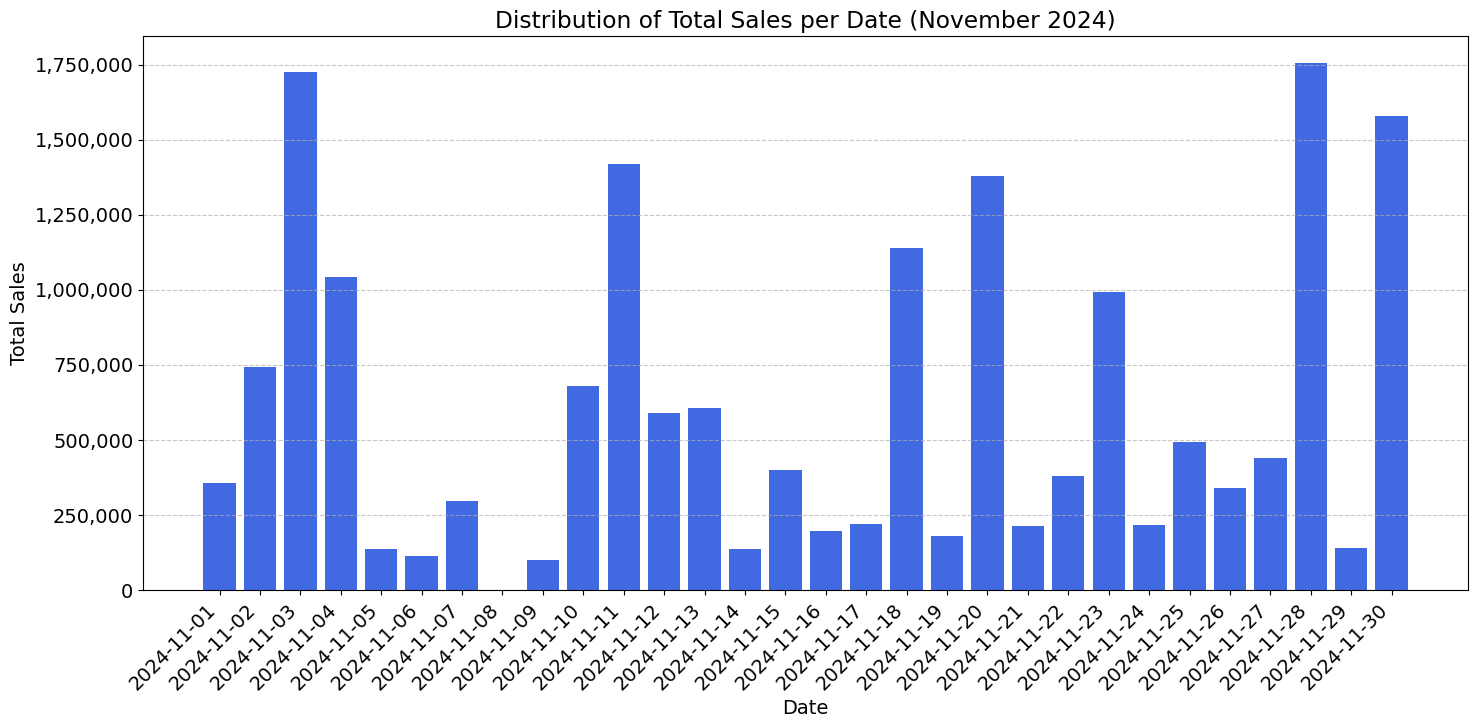

In [24]:
descriptive_statistics(sales_data, 'november2024', "(November 2024)")

In [25]:
# Calculate the CV and its category for the 'Total Sales' column
cv, assessment = calculate_cv(sales_data, "november2024", "Total Sales")

# Display the results
print(f"‣ Coefficient of Variation (CV): {cv:.2f}%")
print(f"‣ Assessment: {assessment}")

‣ Coefficient of Variation (CV): 118.56%
‣ Assessment: High variation (Data fluctuates widely and is not stable.)


In [26]:
advanced_analysis(sales_data, "november2024", "November 2024")

‣ Majority of customers are registered (1).
‣ Majority of customers are not resellers. (0).


‣ Number of customers who made transactions in November 2024 : 74
‣ Number of unregistered customers who made transactions in November 2024: 44
‣ Total sales in November 2024 : 18.017.801
‣ Average sales in November 2024 per customer : 243,483.80


‣ Total sales from resellers in November 2024: 10.230.576
‣ Number of reseller transactions in November 2024 : 67
‣ Average reseller sales in November 2024 : 152.695




‣ Total Customers : 219
‣ Percentage of active customers in November 2024 : 33.79% (of total customers)
‣ Which means total sales in November 2024 : 18.017.801 come from 33.79% of customers


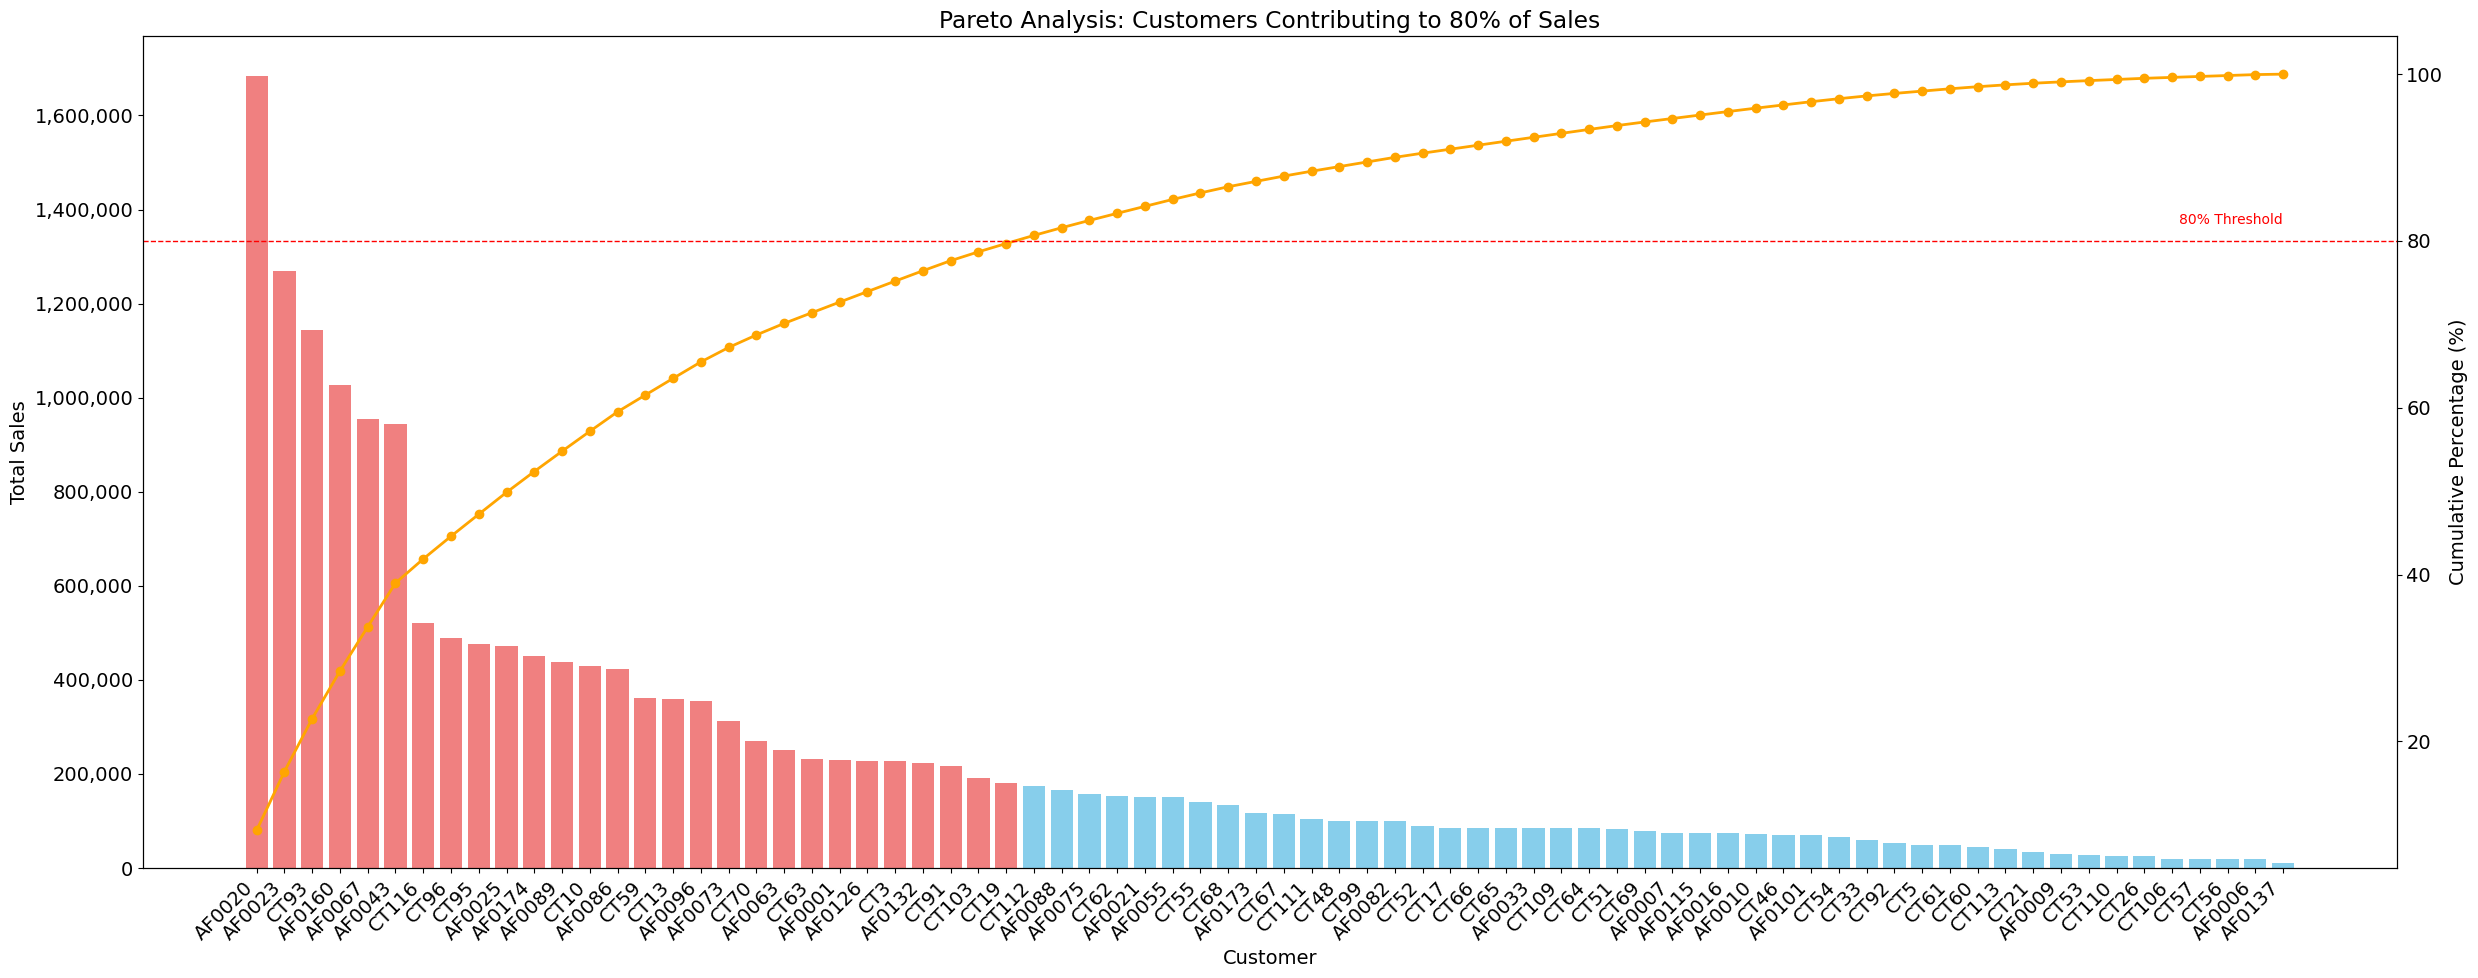

‣ 80% of total sales : 14,359,051.00
‣ Number of customers contributing to 80% of sales: 28
‣ Percentage of customers contributing to 80% of sales: 12.79%
‣ Percentage of transactions contributing to 80% of sales: 15.91%
‣ List of customer names contributing to 80% of sales :
   ID Customer                   Name  Total Sales Cumulative Percentage  \
0       AF0020                BU DEWI      1684000                  9.35   
1       AF0023        MBA MILA RESELL      1269000                 16.39   
2         CT93               BU FITRI      1143000                 22.73   
3       AF0160        TYA UMMU AISYAH      1028000                 28.44   
4       AF0067            YUNI ESTIKA       955000                 33.74   
5       AF0043               MBA ERNA       945000                 38.98   
6        CT116          DAPURE AISYAH       520410                 41.87   
7         CT96                MAMA AI       490000                 44.59   
8         CT95              MBA WINDU  

In [27]:
pareto_analysis (sales_data, "november2024", "November 2024", 44, 175)

## 📆 Desember 2024



        Date Invoice No. ID Customer           Name  Registered in the Form  \
0 2024-12-01  AF12240008        CT73  MBA WAHYU AYU                       0   
1 2024-12-01  AF12240001      AF0001     ABU AISYAH                       1   
2 2024-12-01  AF12240003        CT74    UMMU YASMIN                       0   
3 2024-12-01  AF12240004        CT98       BU FENTY                       0   
4 2024-12-01  AF12240006         CT3       BU PANCA                       0   

   Reseller  Total Sales  
0         0       116000  
1         0        82200  
2         0        48000  
3         0       186000  
4         0        50000  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    149 non-null    datetime64[ns]
 1   Invoice No.             149 non-null    object        
 2   ID Custome



                                Date    Total Sales
count                            149     149.000000
mean   2024-12-17 07:43:53.557047040  108280.268456
min              2024-12-01 00:00:00    5000.000000
25%              2024-12-11 00:00:00   45000.000000
50%              2024-12-17 00:00:00   82200.000000
75%              2024-12-25 00:00:00  140000.000000
max              2024-12-31 00:00:00  860000.000000
std                              NaN  104841.903670




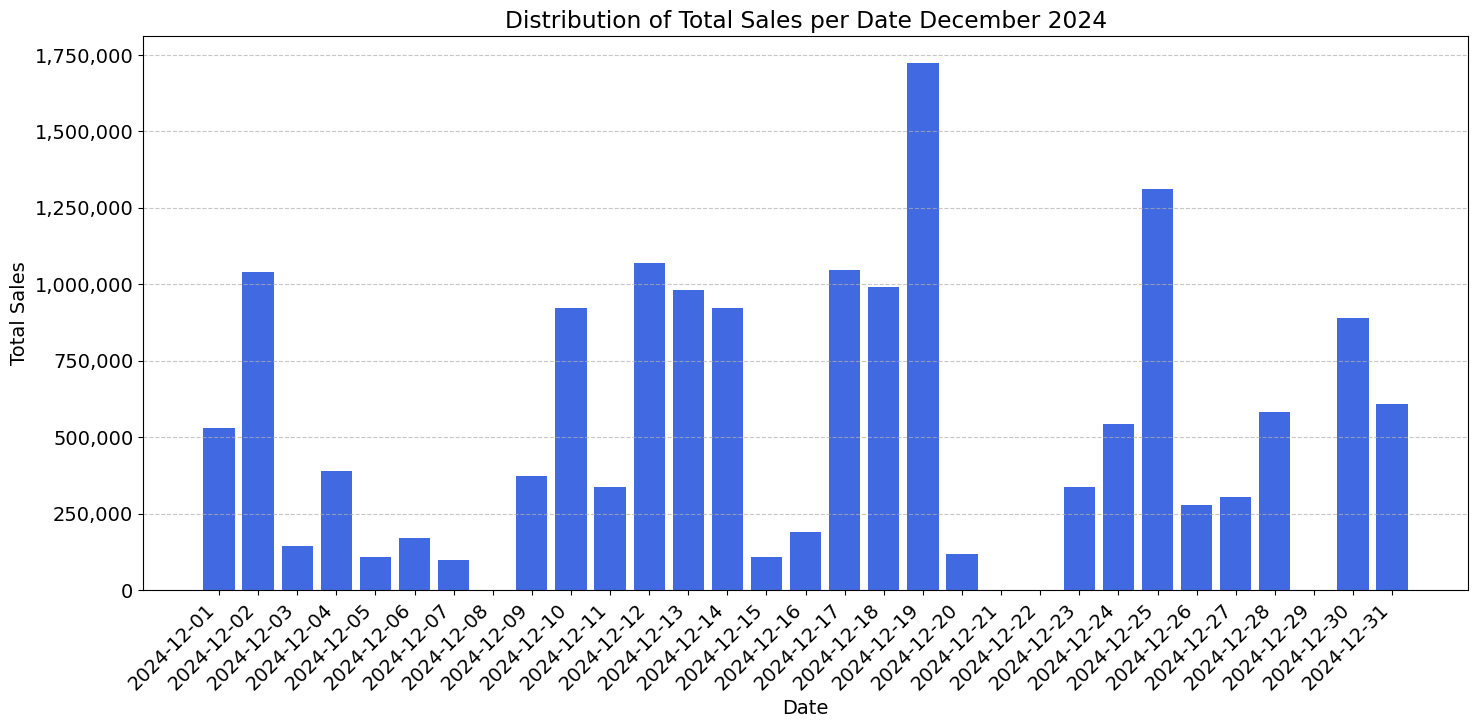

In [28]:
descriptive_statistics(sales_data, 'december2024', 'December 2024')

In [29]:
cv, assessment = calculate_cv(sales_data, "december2024", "Total Sales")

print(f"‣ Koefisien Variasi (CV): {cv:.2f}%")
print(f"‣ Penilaian: {assessment}")

‣ Koefisien Variasi (CV): 96.50%
‣ Penilaian: High variation (Data fluctuates widely and is not stable.)


In [30]:
advanced_analysis(sales_data, "december2024", "December 2024")

‣ Majority of customers are not registered (0).
‣ Majority of customers are not resellers. (0).


‣ Number of customers who made transactions in December 2024 : 74
‣ Number of unregistered customers who made transactions in December 2024: 47
‣ Total sales in December 2024 : 16.133.760
‣ Average sales in December 2024 per customer : 218,023.78


‣ Total sales from resellers in December 2024: 7.405.600
‣ Number of reseller transactions in December 2024 : 42
‣ Average reseller sales in December 2024 : 176.324




‣ Total Customers : 224
‣ Percentage of active customers in December 2024 : 33.04% (of total customers)
‣ Which means total sales in December 2024 : 16.133.760 come from 33.04% of customers


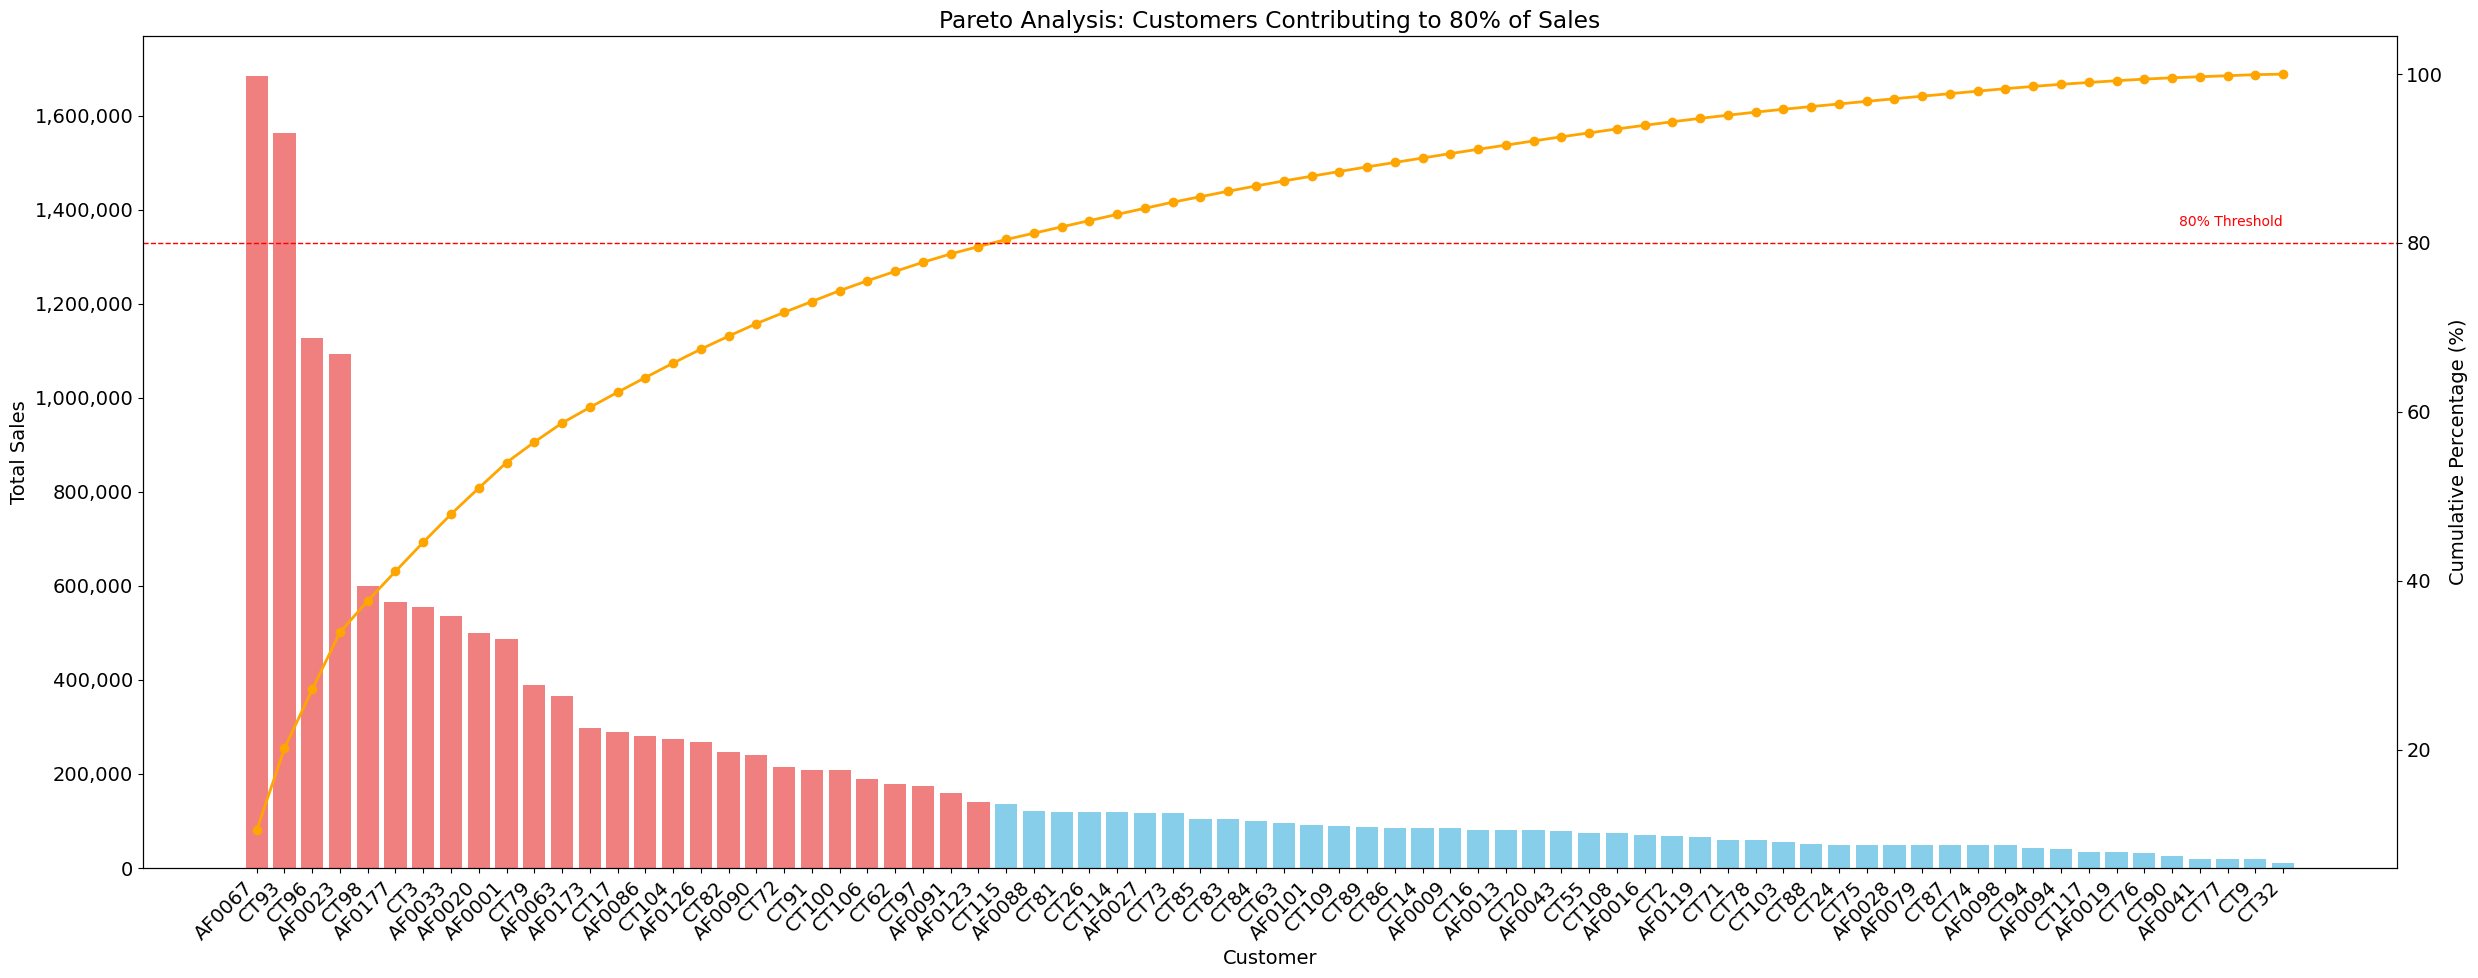

‣ 80% of total sales : 12,837,960.00
‣ Number of customers contributing to 80% of sales: 27
‣ Percentage of customers contributing to 80% of sales: 12.05%
‣ Percentage of transactions contributing to 80% of sales: 18.12%
‣ List of customer names contributing to 80% of sales :
   ID Customer             Name  \
0       AF0067      YUNI ESTIKA   
1         CT93         BU FITRI   
2         CT96          MAMA AI   
3       AF0023         MBA MILA   
4         CT98         BU FENTY   
5       AF0177             ANTY   
6          CT3         BU PANCA   
7       AF0033  BU LUSI BANDENG   
8       AF0020          bu dewi   
9       AF0001       ABU AISYAH   
10        CT79        PAK SISWO   
11      AF0063      UMMU FAUZAN   
12      AF0173        UMMU MUSA   
13        CT17         BU YUYUN   
14      AF0086        MBA KARIS   
15       CT104       MBA CONYTA   
16      AF0126    UMMU AIYAH B4   
17        CT82      UMMU AZIZAH   
18      AF0090         BU CATUR   
19        CT72     AYU 

In [31]:
pareto_analysis (sales_data, "december2024", "December 2024", 47, 177)

## 📚 Comparison Across Months

In [32]:
# Transaction frequency for each customer per month

# combine 3 months of data into 1 dataframe
october = pd.read_excel(sales_data, sheet_name="october2024")
november = pd.read_excel(sales_data, sheet_name="november2024")
december = pd.read_excel(sales_data, sheet_name="december2024")

customer_data_file = 'registered_customers.xlsx'
registered_customers = pd.read_excel(customer_data_file, sheet_name="Registered Customers")

# add month column
october["Month"] = "October"
november["Month"] = "November"
december["Month"] = "December"

# combine all data
sales_data = pd.concat([october, november, december], ignore_index=True)

# transactions per customer per month
transactions_per_month = sales_data.groupby(["Month", "ID Customer"]).size().reset_index(name="Number of Transactions")

# total transactions from all 3 months
total_transactions = sales_data.groupby("ID Customer").size().reset_index(name="Total Transactions")

display(HTML('<span style="font-size:19px; font-weight:bold;">Number of transactions per customer per month:</span>'))

transactions_per_month

,Month,ID Customer,Number of Transactions
0,December,CT72,2
1,December,AF0001,9
2,December,AF0009,1
3,December,AF0013,1
4,December,AF0016,3
5,December,AF0019,2
6,December,AF0020,2
7,December,AF0023,9
8,December,AF0027,1
9,December,AF0028,1


In [33]:
customer_data_list = []
quartile_list = []

# Loop through each month
for month in transactions_per_month['Month'].unique():
    df_month = transactions_per_month[transactions_per_month['Month'] == month].copy()

    # Calculate quartiles for categorization
    q1 = df_month['Number of Transactions'].quantile(0.25)
    q3 = df_month['Number of Transactions'].quantile(0.75)
    quartile_list.append({'Month': month, 'Q1': q1, 'Q3': q3})

    # Categorization
    def categorize(x):
        if x <= q1:
            return 'Low'
        elif x <= q3:
            return 'Medium'
        else:
            return 'High'

    df_month['Category'] = df_month['Number of Transactions'].apply(categorize)

    # Set category column to a fixed order
    category_order = pd.CategoricalDtype(['High', 'Medium', 'Low'], ordered=True)
    df_month['Category'] = df_month['Category'].astype(category_order)

    customer_data_list.append(df_month)

customer_category_results = pd.concat(customer_data_list, ignore_index=True)

customer_category_results = customer_category_results.sort_values(by=['Month', 'Category'])

df_quartiles = pd.DataFrame(quartile_list)

# Display result
display(customer_category_results)

,Month,ID Customer,Number of Transactions,Category
1,December,AF0001,9,High
4,December,AF0016,3,High
7,December,AF0023,9,High
13,December,AF0063,4,High
14,December,AF0067,4,High
16,December,AF0086,3,High
18,December,AF0090,3,High
27,December,AF0177,4,High
30,December,CT104,3,High
39,December,CT17,3,High


In [34]:
df_quartiles

,Month,Q1,Q3
0,December,1.0,2.0
1,November,1.0,3.0
2,October,1.0,2.0


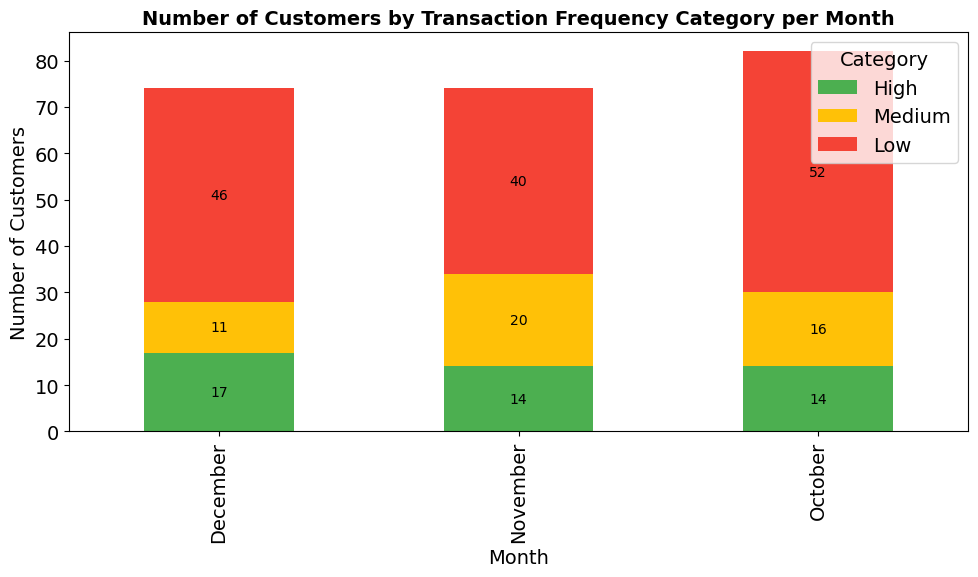

In [35]:
# Count number of customers per category each month
category_df = (
    customer_category_results
    .groupby(['Month', 'Category'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['High', 'Medium', 'Low'])  # category order
)

# Plot
ax = category_df.plot(
    kind='bar',
    stacked=True,
    color=['#4CAF50', '#FFC107', '#F44336'],  # green, yellow, red
    figsize=(10, 6)
)

# Add number labels in the middle of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            str(int(p.get_height())),
            (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height() / 2),
            ha='center', va='center', fontsize=10, color='black'
        )

plt.title("Number of Customers by Transaction Frequency Category per Month", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

In [36]:
display(HTML('<span style="font-size:19px; font-weight:bold;">Total transactions per customer during October, November, and December (2024):</span>'))
total_transactions

,ID Customer,Total Transactions
0,CT72,2
1,AF0001,25
2,AF0005,2
3,AF0006,1
4,AF0007,2
5,AF0009,4
6,AF0010,1
7,AF0013,2
8,AF0016,9
9,AF0017,1


In [37]:
# Filter sales data only for registered customers
sales_data_registered = sales_data[sales_data["Registered in the Form"] == 1].copy()

# Total transactions per customer across all months (registered customers)
total_transactions = sales_data_registered.groupby("ID Customer").size().reset_index(name="Total Transactions")

registered_customers.rename(columns={"ID Customer": "ID Customer"}, inplace=True)

registered_customers["ID Customer"] = registered_customers["ID Customer"].astype(str).str.strip()
sales_data_registered["ID Customer"] = sales_data_registered["ID Customer"].astype(str).str.strip()

# Identify registered customers who did not make any transactions
registered_customers["Has Transaction"] = registered_customers["ID Customer"].isin(total_transactions["ID Customer"])

no_transactions = registered_customers[~registered_customers["Has Transaction"]].reset_index(drop=True)

#### • Pelanggan terdaftar yang tidak brtransaksi selama bulan Oktober, November, Desember :

In [38]:
no_transactions

,ID Customer,Timestamp,Nama Panggilan :,"Social Media Accounts: (Facebook, Instagram, TikTok, etc.)\nExample:\nInstagram: dapure_aisyah\nFacebook: ummu aisyah suprianty\n\n✍️ If none, write ""None""",Joined Al Fath TSA: (multiple choices allowed),Items Purchased at Al Fath TSA (General Store):,Purpose of shopping at Al Fath TSA (general store): (multiple answers allowed),Impression from shopping at Al Fath TSA (general store):,Feedback & Suggestions for Al Fath TSA (general store):,Unnamed: 9,Has Transaction
0,AF0002,2023/04/04 12:21:40 PM GMT+7,NaN,Kacang tuban,NaN,NaN,Untuk dijual lagi,Barang yg dibeli bagus_ bagus Jadi yg beli dis...,Saran sy semoga kedepannya banyak pilihan bara...,NaT,False
1,AF0003,2023/04/04 1:35:30 PM GMT+7,NaN,Tidak ada,Al Fath tsa WAG,Kacang tuban,Untuk dijual lagi,Barangnya oke,Semoga makin banyak pilihan barang yang dijual,2023-04-04,False
2,AF0004,2023/04/05 8:20:08 AM GMT+7,NaN,FB : Lusi Prihantini\nIG : hamisya_foods,Al Fath tsa WAG;Al Fath tsa Telegram,"Buah, frozen foods, kue kue",Pemakaian pribadi,"Barang bagus, amanah, pengiriman cepat",Overall bagus...,2023-04-05,False
3,AF0008,2023/06/18 1:51:15 PM GMT+7,NaN,Ig : ikyashop1,Al Fath tsa WAG,Sosis,Pemakaian pribadi;Untuk produksi / diolah lagi...,"Respon seller cepat, komunikatif.",Tidak ada,2023-06-18,False
4,AF0011,2023/07/12 3:09:46 PM GMT+7,NaN,Tidak ada,Al Fath tsa WAG;Al Fath tsa Telegram,Makanan,Pemakaian pribadi,Enak.kadang2 aja kyk tape tll matang jadi mani...,Managemen waktu utk makanan yang butuh diprodu...,2023-07-12,False
5,AF0012,2023/07/12 3:16:45 PM GMT+7,NaN,IG : keluarga _gemoy,Al Fath tsa WAG,"Dulu pernah beli apa ya, afwan lupa",Pemakaian pribadi,InsyaaAllaah amanah,Tidak ada,2023-07-12,False
6,AF0014,2023/07/12 3:31:43 PM GMT+7,NaN,IG: Dapoer Shanty\nTiktok: dapoershanty\nFb: w...,Al Fath tsa WAG,"Keju, buah smokedbeef, sosis",Untuk produksi / diolah lagi,Layanan ramah cepat sampai,Tingkatkan dan pertahankan,2023-07-12,False
7,AF0015,2023/07/12 3:33:24 PM GMT+7,NaN,IG: Emcy Ummu Sahla\nFB : Emcy Enny Rosita,Al Fath tsa WAG;Al Fath tsa Telegram,Ayam,Pemakaian pribadi,Agak slow respon. Mungkin pelanggan banyak.,Langsung minta info lengkap setelah konsumen p...,2023-07-12,False
8,AF0018,2023/07/13 9:01:39 AM GMT+7,NaN,Fb : retno ummu aliyah,Al Fath tsa WAG,Snack,Pemakaian pribadi;Untuk produksi / diolah lagi...,Pelayanan dan respon sangat baik,Lebih banyak promo dan harga diskon ðŸ˜˜,2023-02-22,False
9,AF0024,2023/07/18 2:57:54 PM GMT+7,NaN,dapurlittleyaya,Al Fath tsa WAG;Al Fath tsa Telegram,"Bahan pangan, buah, frozen food, dll",Pemakaian pribadi;Untuk produksi / diolah lagi...,Barang bagus,Boleh diadakan promo ongkir um hehe,2023-07-18,False


In [39]:
no_transactions_count = no_transactions['ID Customer'].count()
print(f'Number of customers with no transactions = {no_transactions_count}')

Number of customers with no transactions = 124


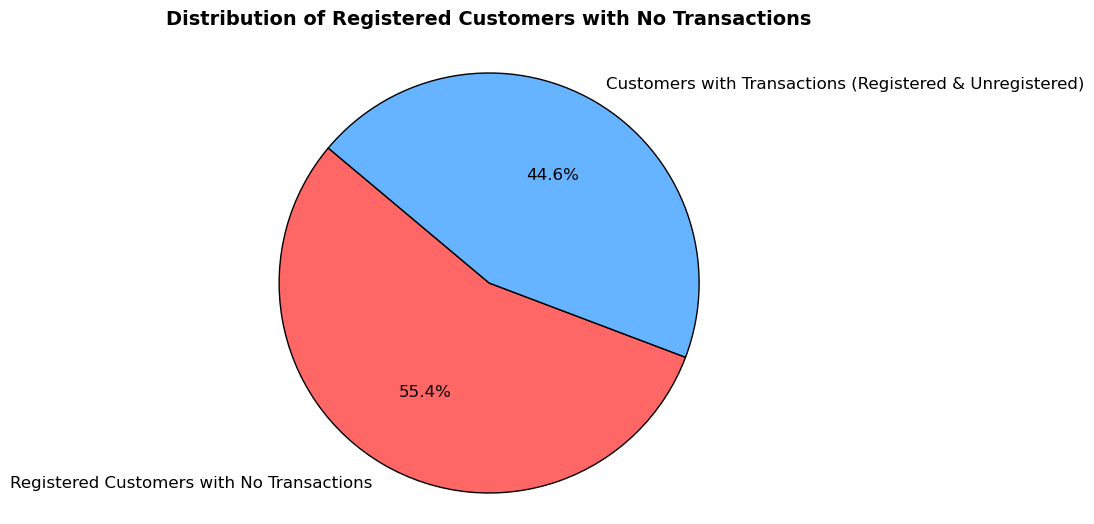

In [40]:
active_customers = 224 - no_transactions_count  # Total customers - no transactions

# store in Series
category_counts = pd.Series({
    'Registered Customers with No Transactions': no_transactions_count,
    'Customers with Transactions (Registered & Unregistered)': active_customers
})

custom_colors = ['#ff6666', '#66b3ff']  # red, blue

plt.figure(figsize=(10, 6))

wedges, texts, autotexts = plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=custom_colors,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Distribution of Registered Customers with No Transactions", fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')  # keep the pie chart circular
plt.show()

In [41]:
# Identify transaction months for each customer
transaction_month_details = sales_data.groupby("ID Customer")["Month"].apply(lambda x: ', '.join(sorted(x.unique())))
transaction_month_count = sales_data.groupby("ID Customer")["Month"].nunique()

# Filter customers who only made transactions in one or two months
filtered_customers = transaction_month_count[(transaction_month_count == 1) | (transaction_month_count == 2)]

# Combine active month details
filtered_details = transaction_month_details[filtered_customers.index]

# Create the final result DataFrame
result = pd.DataFrame({
    "ID Customer": filtered_customers.index,
    "Active Months": filtered_details.values
})

In [42]:
display(HTML('<span style="font-size:19px; font-weight:bold;"> Customers who do not shop every month: </span>'))
result

,ID Customer,Active Months
0,CT72,December
1,AF0005,October
2,AF0006,November
3,AF0007,"November, October"
4,AF0010,November
5,AF0013,"December, October"
6,AF0017,October
7,AF0019,December
8,AF0021,November
9,AF0022,October


#### RFM analysis

In [43]:
import datetime as dt
snapshot_date = dt.datetime(2024, 12, 31)

In [44]:
# 1. Grouping data by Customer ID to calculate RFM metrics
rfm = sales_data.groupby('ID Customer').agg({
    'Name':'first',
    'Date': lambda x: (snapshot_date - x.max()).days,  # Recency (Days since last purchase)
    'ID Customer': 'count',                           # Frequency (Number of purchases)
    'Total Sales': 'sum',                             # Monetary (Total spend)
    'Registered in the Form': 'first',
    'Reseller': 'first'
})

# 2. Renaming columns for clarity
rfm.rename(columns={
    'Date': 'Recency',
    'ID Customer': 'Frequency',
    'Total Sales': 'Monetary'
}, inplace=True)

# 3. Defining the Scoring Logic (Assigning points 1-4)
def get_rfm_score(recency, frequency, monetary):
    # Recency: Higher score for more recent activity
    r_score = 3 if recency <= 30 else 2 if 31 <= recency <= 59 else 1
    
    # Frequency: Higher score for more frequent purchases
    f_score = 4 if frequency >= 12 else 3 if 6 <= frequency <= 12 else 2 if 3 <= frequency <= 5 else 1
    
    # Monetary: Higher score for higher total spend
    m_score = 4 if monetary > 500000 else 3 if 300000 <= monetary <= 500000 else 2 if 100000 <= monetary <= 299000 else 1
    
    return r_score, f_score, m_score

# Applying the scoring function to create R, F, and M columns
rfm[['R', 'F', 'M']] = rfm.apply(lambda row: pd.Series(get_rfm_score(row['Recency'], row['Frequency'], row['Monetary'])), axis=1)

# 4. Defining Customer Segments based on scores
def categorize_customer(r, f, m):
    if r == 3 and f == 4 and m == 4:
        return "Best Customers"
    elif r == 3 and (f in [3, 4]) and (m in [3, 4]):
        return "Loyal Customers"
    elif r == 3 and (f in [3, 4]) and (m in [1, 2]):
        return "Budget Buyers"
    elif r in [1, 2] and f in [1, 2] and m in [2, 3]:
        return "Churn Risk"
    elif r == 1 and f == 1 and m == 1:
        return "Lost Customers"
    elif r in [1, 2, 3] and f in [1, 2] and m == 4:
        return "Big Spenders"
    elif r == 3 and f in [1, 2] and m in [2, 3, 4]:
        return "Potential Customers"
    else:
        return "OTHER"

# Adding the Category column based on RFM results
rfm["Category"] = rfm.apply(lambda row: categorize_customer(row["R"], row["F"], row["M"]), axis=1)

# Display result
rfm

,Name,Recency,Frequency,Monetary,Registered in the Form,Reseller,R,F,M,Category
ID Customer,,,,,,,,,,
CT72,AYU UMMU ISA,22,2,215000,0,0,3,1,2,Potential Customers
AF0001,ABU AISYAH,6,25,1008245,1,0,3,4,4,Best Customers
AF0005,ERIKA,65,2,221500,1,1,1,1,2,Churn Risk
AF0006,UMMU YAHYA,50,1,20000,1,0,2,1,1,OTHER
AF0007,MBA TANTI,33,2,218000,1,0,2,1,2,Churn Risk
AF0009,UMMU ADHWA,29,4,124000,1,1,3,2,2,Potential Customers
AF0010,MBA SRI,58,1,73000,1,0,2,1,1,OTHER
AF0013,MBA LUSI GANDUL,0,2,180000,1,0,3,1,2,Potential Customers
AF0016,UMMU KHAULAH,8,9,235600,1,0,3,3,2,Budget Buyers


In [45]:
from IPython.display import display, Markdown

In [46]:
# 1. Creating separate DataFrames for each customer category
best_customers = rfm[rfm["Category"] == "Best Customers"]
loyal_customers = rfm[rfm["Category"] == "Loyal Customers"]
budget_buyers = rfm[rfm["Category"] == "Budget Buyers"]
churn_risk = rfm[rfm["Category"] == "Churn Risk"]
lost_customers = rfm[rfm["Category"] == "Lost Customers"]
big_spenders = rfm[rfm["Category"] == "Big Spenders"]
potential_customers = rfm[rfm["Category"] == "Potential Customers"]
other_customers = rfm[rfm["Category"] == "OTHER"]

# 2. Displaying the count of customers in each category
display(Markdown("**Number of customers in each category:**"))
category_counts = rfm["Category"].value_counts()
display(category_counts)

# 3. Displaying the DataFrames for each specific category
display(Markdown("**- Best Customers:**"))
display(best_customers)
print('\n')

display(Markdown("**- Loyal Customers:**"))
display(loyal_customers)
print('\n')

display(Markdown("**- Budget Buyers:**"))
display(budget_buyers)
print('\n')

display(Markdown("**- Churn Risk:**"))
display(churn_risk)
print('\n')

display(Markdown("**- Lost Customers:**"))
display(lost_customers)
print('\n')

display(Markdown("**- Big Spenders:**"))
display(big_spenders)
print('\n')

display(Markdown("**- Potential Customers:**"))
display(potential_customers)
print('\n')

display(Markdown("**- OTHER Customers:**"))
display(other_customers)

**Number of customers in each category:**

Category
OTHER                  42
Potential Customers    35
Churn Risk             33
Lost Customers         21
Loyal Customers        10
Big Spenders            9
Best Customers          3
Budget Buyers           2
Name: count, dtype: int64

**- Best Customers:**

,Name,Recency,Frequency,Monetary,Registered in the Form,Reseller,R,F,M,Category
ID Customer,,,,,,,,,,
AF0001,ABU AISYAH,6,25,1008245,1,0,3,4,4,Best Customers
AF0023,MBA MILA,1,27,3112300,1,1,3,4,4,Best Customers
CT93,bu FITRI,1,27,3848700,0,1,3,4,4,Best Customers


**- Loyal Customers:**

...

,Name,Recency,Frequency,Monetary,Registered in the Form,Reseller,R,F,M,Category
ID Customer,,,,,,,,,,
AF0025,UMMU RUQAYYAH,31,5,563000,1,0,2,2,4,Big Spenders
AF0033,bu lusi bandeng,17,4,1048250,1,0,3,2,4,Big Spenders
AF0060,UMMU FATHIR,66,2,570000,1,0,1,1,4,Big Spenders
AF0089,UMMU NAUFAL RESELL,34,4,802166,1,1,2,2,4,Big Spenders
AF0126,UMMU AISYAH B4,1,5,635000,1,0,3,2,4,Big Spenders
AF0177,ANTY,6,4,565200,1,1,3,2,4,Big Spenders
CT13,RUNDa,37,4,760000,0,1,2,2,4,Big Spenders
CT95,MBA WINDU RESELL,33,5,806000,0,1,2,2,4,Big Spenders
CT98,BU FENTY,8,4,699000,0,0,3,2,4,Big Spenders


**- Potential Customers:**

,Name,Recency,Frequency,Monetary,Registered in the Form,Reseller,R,F,M,Category
ID Customer,,,,,,,,,,
CT72,AYU UMMU ISA,22,2,215000,0,0,3,1,2,Potential Customers
AF0009,UMMU ADHWA,29,4,124000,1,1,3,2,2,Potential Customers
AF0013,MBA LUSI GANDUL,0,2,180000,1,0,3,1,2,Potential Customers
AF0027,SANDRA,21,3,180000,1,0,3,2,2,Potential Customers
AF0090,BU CATUR,3,3,240000,1,1,3,2,2,Potential Customers
AF0091,BU TRI,6,1,160000,1,1,3,1,2,Potential Customers
AF0101,TEH RINA,12,2,160500,1,0,3,1,2,Potential Customers
AF0119,ANITA,5,2,135000,1,0,3,1,2,Potential Customers
AF0123,NANIT,12,1,140000,1,0,3,1,2,Potential Customers


**- OTHER Customers:**

,Name,Recency,Frequency,Monetary,Registered in the Form,Reseller,R,F,M,Category
ID Customer,,,,,,,,,,
AF0006,UMMU YAHYA,50,1,20000,1,0,2,1,1,OTHER
AF0010,MBA SRI,58,1,73000,1,0,2,1,1,OTHER
AF0019,MBA SYIFA,14,2,33400,1,0,3,1,1,OTHER
AF0028,BU ANDINI BELNIS,12,1,50000,1,0,3,1,1,OTHER
AF0041,MBA ISNA,7,2,60000,1,0,3,1,1,OTHER
AF0075,MBA TANISI,41,9,368000,1,1,2,3,3,OTHER
AF0079,MBA SALMA,21,1,49000,1,0,3,1,1,OTHER
AF0094,UMMU AZZAM,21,1,40000,1,1,3,1,1,OTHER
AF0098,DWI MURTI,21,1,48000,1,0,3,1,1,OTHER


#### Pie Chart RFM

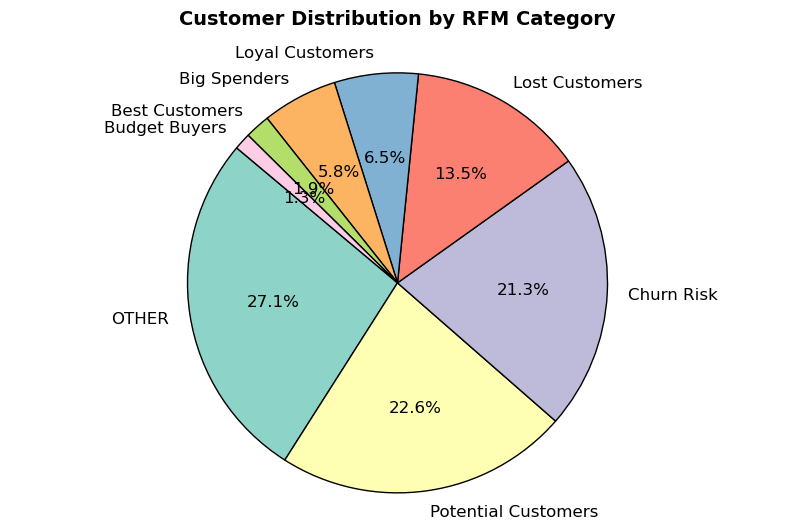

In [47]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Set3.colors  # Pastel colors
wedges, texts, autotexts = plt.pie(
    category_counts, labels=category_counts.index, autopct='%1.1f%%',
    startangle=140, colors=colors, textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'black'}
)

# Title: Customer Distribution Based on RFM Categories
plt.title("Customer Distribution by RFM Category", fontsize=14, fontweight='bold', pad=20)

plt.axis('equal')  # Ensures the pie chart is drawn as a circle
plt.show()

#### Analisis apakah ada pelanggan yang menyumbang 80% penjualan dalam ketiga bulan itu.

In [48]:
# Loading Pareto tables for each month
october_pareto_table = pd.read_excel('pareto_table_oct_2024.xlsx')
november_pareto_table = pd.read_excel('pareto_table_nov_2024.xlsx')
december_pareto_table = pd.read_excel('pareto_table_dec_2024.xlsx')

In [49]:
# 1. Getting the list of Customer IDs who contributed to 80% of sales each month
october_customers = set(october_pareto_table[october_pareto_table["Above 80%"] == True]["ID Customer"])
november_customers = set(november_pareto_table[november_pareto_table["Above 80%"] == True]["ID Customer"])
december_customers = set(december_pareto_table[december_pareto_table["Above 80%"] == True]["ID Customer"])

# 2. Finding customers who appear consistently in all three months
consistent_customers = october_customers & november_customers & december_customers

# Display the list of consistent customers
consistent_customers

{'AF0001', 'AF0020', 'AF0023', 'AF0086', 'AF0126', 'CT93', 'CT96'}